In [1]:
# Word Frequency Shift Across Domains
### Dataset: Reuters-21578
#The project analyzes how vocabulary usage differs across news domains.

In [2]:
!pip install beautifulsoup4 nltk matplotlib pandas



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
## 1. Dataset Extraction
# The Reuters-21578 dataset is stored in SGML format.  
# We parse the files and extract article text along with topic labels.

In [4]:
import os
from bs4 import BeautifulSoup


In [5]:
DATA_PATH = "reuters21578"

In [6]:
files = os.listdir(DATA_PATH)

print("Total files:", len(files))
print(files[:10])

Total files: 22
['reut2-000.sgm', 'reut2-001.sgm', 'reut2-002.sgm', 'reut2-003.sgm', 'reut2-004.sgm', 'reut2-005.sgm', 'reut2-006.sgm', 'reut2-007.sgm', 'reut2-008.sgm', 'reut2-009.sgm']


In [7]:
file_path = os.path.join(DATA_PATH, "reut2-000.sgm")

with open(file_path, encoding="latin-1") as f:
    data = f.read()

print(data[:1000])

<!DOCTYPE lewis SYSTEM "lewis.dtd">
<REUTERS TOPICS="YES" LEWISSPLIT="TRAIN" CGISPLIT="TRAINING-SET" OLDID="5544" NEWID="1">
<DATE>26-FEB-1987 15:01:01.79</DATE>
<TOPICS><D>cocoa</D></TOPICS>
<PLACES><D>el-salvador</D><D>usa</D><D>uruguay</D></PLACES>
<PEOPLE></PEOPLE>
<ORGS></ORGS>
<EXCHANGES></EXCHANGES>
<COMPANIES></COMPANIES>
<UNKNOWN> 
&#5;&#5;&#5;C T
&#22;&#22;&#1;f0704&#31;reute
u f BC-BAHIA-COCOA-REVIEW   02-26 0105</UNKNOWN>
<TEXT>&#2;
<TITLE>BAHIA COCOA REVIEW</TITLE>
<DATELINE>    SALVADOR, Feb 26 - </DATELINE><BODY>Showers continued throughout the week in
the Bahia cocoa zone, alleviating the drought since early
January and improving prospects for the coming temporao,
although normal humidity levels have not been restored,
Comissaria Smith said in its weekly review.
    The dry period means the temporao will be late this year.
    Arrivals for the week ended February 22 were 155,221 bags
of 60 kilos making a cumulative total for the season of 5.93
mln against 5.81 at the sa

In [8]:
soup = BeautifulSoup(data, "html.parser")

articles = soup.find_all("reuters")

print("Total articles in this file:", len(articles))

Total articles in this file: 1000


In [9]:
article = articles[0]

print(article.prettify()[:1000])

<reuters cgisplit="TRAINING-SET" lewissplit="TRAIN" newid="1" oldid="5544" topics="YES">
 <date>
  26-FEB-1987 15:01:01.79
 </date>
 <topics>
  <d>
   cocoa
  </d>
 </topics>
 <places>
  <d>
   el-salvador
  </d>
  <d>
   usa
  </d>
  <d>
   uruguay
  </d>
 </places>
 <people>
 </people>
 <orgs>
 </orgs>
 <exchanges>
 </exchanges>
 <companies>
 </companies>
 <unknown>
  C T
f0704reute
u f BC-BAHIA-COCOA-REVIEW   02-26 0105
 </unknown>
 <text>
  
  <title>
   BAHIA COCOA REVIEW
  </title>
  <dateline>
   SALVADOR, Feb 26 -
  </dateline>
  <body>
   Showers continued throughout the week in
the Bahia cocoa zone, alleviating the drought since early
January and improving prospects for the coming temporao,
although normal humidity levels have not been restored,
Comissaria Smith said in its weekly review.
    The dry period means the temporao will be late this year.
    Arrivals for the week ended February 22 were 155,221 bags
of 60 kilos making a cumulative total for the season of 5.

In [10]:
article = articles[0]

topics = article.find("topics")
body = article.find("body")

if topics and body:
    
    topic_list = topics.find_all("d")
    
    topic_names = [t.text for t in topic_list]
    
    print("Topics:", topic_names)
    print()
    print("Article text:")
    print(body.text[:500])

Topics: ['cocoa']

Article text:
Showers continued throughout the week in
the Bahia cocoa zone, alleviating the drought since early
January and improving prospects for the coming temporao,
although normal humidity levels have not been restored,
Comissaria Smith said in its weekly review.
    The dry period means the temporao will be late this year.
    Arrivals for the week ended February 22 were 155,221 bags
of 60 kilos making a cumulative total for the season of 5.93
mln against 5.81 at the same stage last year. Again it seem


In [11]:
documents = []

for file in os.listdir(DATA_PATH):

    if file.endswith(".sgm"):
        
        path = os.path.join(DATA_PATH, file)

        with open(path, encoding="latin-1") as f:

            soup = BeautifulSoup(f, "html.parser")

            articles = soup.find_all("reuters")

            for article in articles:

                topics = article.find("topics")
                body = article.find("body")

                if topics and body:

                    topic_list = topics.find_all("d")
                    topic_names = [t.text for t in topic_list]

                    # keep only single-topic articles
                    if len(topic_names) == 1:

                        documents.append({
                            "topic": topic_names[0],
                            "text": body.text
                        })

print("Total extracted documents:", len(documents))

Total extracted documents: 8654


In [12]:
documents[0]

{'topic': 'cocoa',
 'text': 'Showers continued throughout the week in\nthe Bahia cocoa zone, alleviating the drought since early\nJanuary and improving prospects for the coming temporao,\nalthough normal humidity levels have not been restored,\nComissaria Smith said in its weekly review.\n    The dry period means the temporao will be late this year.\n    Arrivals for the week ended February 22 were 155,221 bags\nof 60 kilos making a cumulative total for the season of 5.93\nmln against 5.81 at the same stage last year. Again it seems\nthat cocoa delivered earlier on consignment was included in the\narrivals figures.\n    Comissaria Smith said there is still some doubt as to how\nmuch old crop cocoa is still available as harvesting has\npractically come to an end. With total Bahia crop estimates\naround 6.4 mln bags and sales standing at almost 6.2 mln there\nare a few hundred thousand bags still in the hands of farmers,\nmiddlemen, exporters and processors.\n    There are doubts as to h

In [13]:
## 2. Domain Selection
# To ensure sufficient data for analysis, we focus on the following domains:

# - earn
# - acq
# - crude
# - trade
# - money-fx

In [14]:
from collections import Counter

topic_counts = Counter([doc["topic"] for doc in documents])

topic_counts

Counter({'earn': 3735,
         'acq': 2125,
         'crude': 355,
         'trade': 333,
         'money-fx': 259,
         'interest': 211,
         'ship': 156,
         'sugar': 135,
         'coffee': 114,
         'gold': 99,
         'money-supply': 97,
         'gnp': 73,
         'cpi': 68,
         'cocoa': 55,
         'copper': 54,
         'jobs': 48,
         'iron-steel': 46,
         'grain': 45,
         'alum': 45,
         'reserves': 42,
         'nat-gas': 42,
         'ipi': 41,
         'rubber': 39,
         'veg-oil': 37,
         'tin': 30,
         'cotton': 26,
         'bop': 24,
         'wpi': 23,
         'gas': 22,
         'pet-chem': 21,
         'livestock': 20,
         'strategic-metal': 19,
         'retail': 18,
         'orange': 18,
         'housing': 15,
         'zinc': 15,
         'heat': 14,
         'lumber': 12,
         'carcass': 11,
         'silver': 11,
         'fuel': 11,
         'lei': 10,
         'oilseed': 9,
         'lead

In [15]:
selected_domains = ["earn", "acq", "crude", "trade", "money-fx"]

filtered_docs = [doc for doc in documents if doc["topic"] in selected_domains]

print("Documents after filtering:", len(filtered_docs))

Documents after filtering: 6807


In [16]:
Counter([doc["topic"] for doc in filtered_docs])

Counter({'earn': 3735,
         'acq': 2125,
         'crude': 355,
         'trade': 333,
         'money-fx': 259})

In [17]:
## 3. Text Preprocessing
# We clean the text using the following steps:

# - Convert text to lowercase
# - Remove punctuation and numbers
# - Tokenize words
# - Remove stopwords

In [18]:
import nltk
from nltk.corpus import stopwords
import re

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhoomika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
stop_words = set(stopwords.words("english"))

In [21]:
custom_stopwords = {
    "said","reuter","mln","dlrs","pct","vs","would","also"
}

stop_words.update(custom_stopwords)

In [22]:
def preprocess(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    tokens = text.split()
    
    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens

In [23]:
sample_text = filtered_docs[0]["text"]

tokens = preprocess(sample_text)

print(tokens[:30])

['champion', 'products', 'inc', 'board', 'directors', 'approved', 'twoforone', 'stock', 'split', 'common', 'shares', 'shareholders', 'record', 'april', 'company', 'board', 'voted', 'recommend', 'shareholders', 'annual', 'meeting', 'april', 'increase', 'authorized', 'capital', 'stock', 'five', 'shares']


In [24]:
## 4. Domain Word Frequency Analysis
# Word frequencies are computed separately for each domain to analyze vocabulary differences.

In [25]:
from collections import defaultdict, Counter

domain_word_counts = defaultdict(Counter)

In [26]:
for doc in filtered_docs:
    
    topic = doc["topic"]
    
    tokens = preprocess(doc["text"])
    
    domain_word_counts[topic].update(tokens)

In [27]:
domain_word_counts["crude"].most_common(20)

[('oil', 1478),
 ('opec', 458),
 ('prices', 442),
 ('crude', 400),
 ('bpd', 397),
 ('barrel', 294),
 ('production', 292),
 ('last', 276),
 ('price', 271),
 ('barrels', 254),
 ('us', 240),
 ('year', 233),
 ('energy', 209),
 ('petroleum', 198),
 ('company', 182),
 ('output', 179),
 ('market', 178),
 ('one', 165),
 ('saudi', 164),
 ('industry', 163)]

In [28]:
for domain in selected_domains:
    
    print("\nTop words in", domain)
    
    print(domain_word_counts[domain].most_common(15))


Top words in earn
[('cts', 7702), ('net', 5101), ('loss', 4366), ('shr', 4002), ('profit', 2671), ('year', 2368), ('revs', 2332), ('billion', 1892), ('share', 1654), ('note', 1456), ('company', 1314), ('sales', 1211), ('oper', 1118), ('avg', 1081), ('quarter', 1075)]

Top words in acq
[('shares', 2008), ('company', 1987), ('inc', 1905), ('corp', 1422), ('offer', 1212), ('stock', 1203), ('share', 1119), ('group', 1000), ('co', 753), ('common', 749), ('acquisition', 636), ('ltd', 624), ('new', 599), ('merger', 596), ('agreement', 583)]

Top words in crude
[('oil', 1478), ('opec', 458), ('prices', 442), ('crude', 400), ('bpd', 397), ('barrel', 294), ('production', 292), ('last', 276), ('price', 271), ('barrels', 254), ('us', 240), ('year', 233), ('energy', 209), ('petroleum', 198), ('company', 182)]

Top words in trade
[('trade', 1475), ('us', 955), ('billion', 565), ('japan', 471), ('japanese', 374), ('year', 332), ('last', 277), ('exports', 268), ('states', 260), ('countries', 248), ('

In [29]:
## 5. Visualization
# The following graphs illustrate how word frequencies shift across domains.

In [30]:
import matplotlib.pyplot as plt

In [31]:
def plot_top_words(domain, counter, n=10):
    
    words = [w for w, _ in counter.most_common(n)]
    freqs = [f for _, f in counter.most_common(n)]
    
    plt.figure(figsize=(8,4))
    plt.bar(words, freqs)
    plt.title(f"Top {n} Words in {domain} Domain")
    plt.xticks(rotation=45)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    
    plt.show()
    

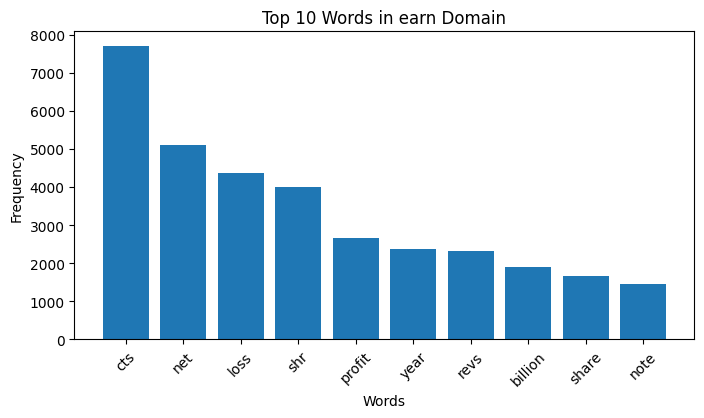

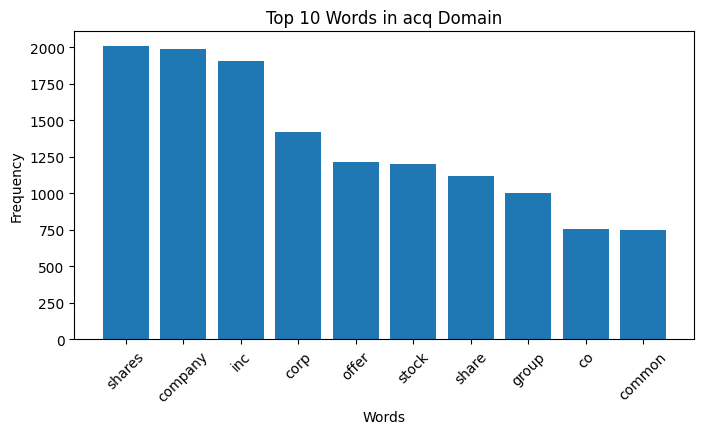

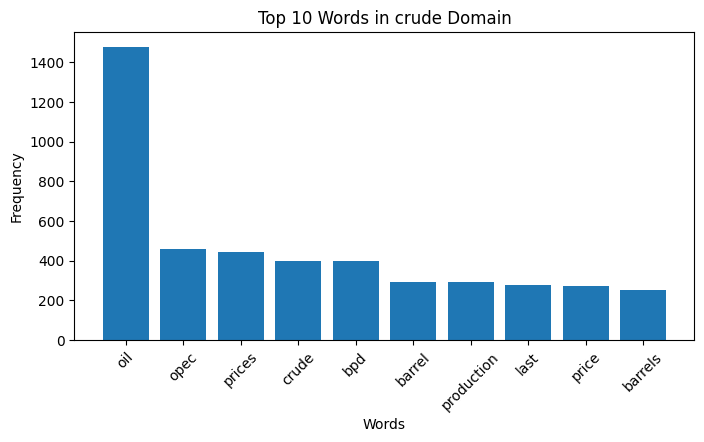

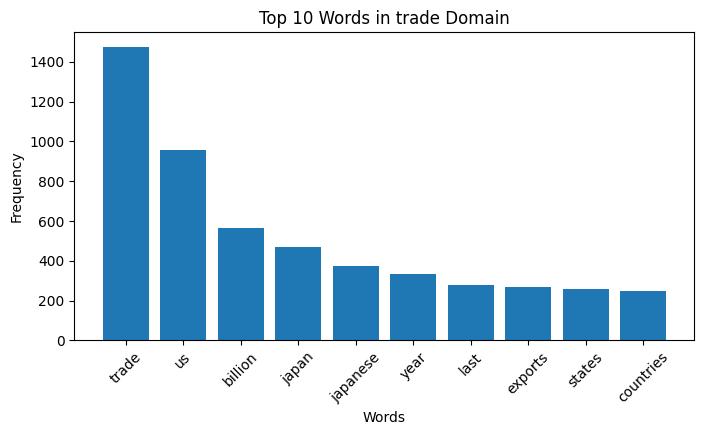

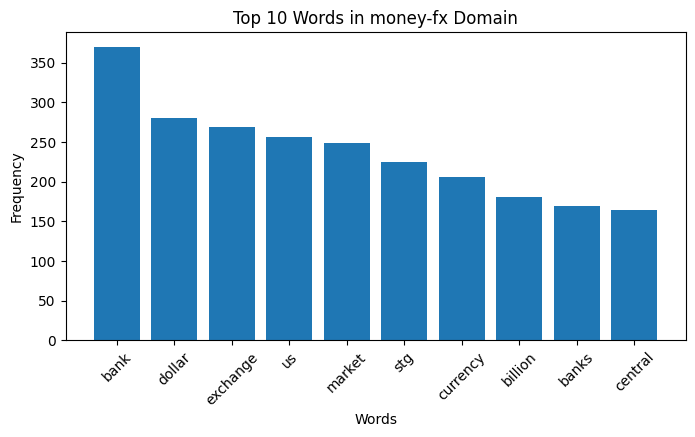

In [32]:
for domain in selected_domains:
    
    plot_top_words(domain, domain_word_counts[domain], 10)

In [33]:
## 6. Distinctive Vocabulary
# We identify words that are highly dominant within a specific domain compared to other domains.
# These words act as domain-specific lexical signatures.

In [34]:
total_word_counts = Counter()

for domain in selected_domains:
    total_word_counts.update(domain_word_counts[domain])

In [35]:
def distinctive_words(domain, n=10):
    
    scores = {}
    
    domain_counts = domain_word_counts[domain]
    
    for word, freq in domain_counts.items():
        
        total_freq = total_word_counts[word]
        
        score = freq / total_freq
        
        scores[word] = score
    
    top_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    return top_words[:n]

In [36]:
for domain in selected_domains:
    
    print("\nDistinctive words for", domain)
    
    words = distinctive_words(domain, 10)
    
    print(words)


Distinctive words for earn
[('oper', 1.0), ('revs', 1.0), ('mths', 1.0), ('processor', 1.0), ('thirdquarter', 1.0), ('derive', 1.0), ('milk', 1.0), ('larsen', 1.0), ('blenders', 1.0), ('ebi', 1.0)]

Distinctive words for acq
[('sedio', 1.0), ('lugano', 1.0), ('technolgy', 1.0), ('dot', 1.0), ('woodco', 1.0), ('tex', 1.0), ('labels', 1.0), ('tags', 1.0), ('chem', 1.0), ('wnx', 1.0)]

Distinctive words for crude
[('copany', 1.0), ('readdress', 1.0), ('yergin', 1.0), ('cera', 1.0), ('opecs', 1.0), ('mlotok', 1.0), ('teach', 1.0), ('lesson', 1.0), ('mizrahi', 1.0), ('slackens', 1.0)]

Distinctive words for trade
[('hailed', 1.0), ('saviour', 1.0), ('limping', 1.0), ('cruzado', 1.0), ('indexation', 1.0), ('customscleared', 1.0), ('fob', 1.0), ('ingvar', 1.0), ('calrsson', 1.0), ('carlsson', 1.0)]

Distinctive words for money-fx
[('gib', 1.0), ('azzam', 1.0), ('relinquish', 1.0), ('sophistication', 1.0), ('euronotes', 1.0), ('innovations', 1.0), ('foreignexchange', 1.0), ('auctions', 1.0), 

In [37]:
## 7. Domain Prediction Demonstration
# Using domain vocabulary distributions, we demonstrate a simple rule-based system that predicts the likely domain of a new article.

In [38]:
domain_total_words = {}

for domain in selected_domains:
    domain_total_words[domain] = sum(domain_word_counts[domain].values())

def predict_domain(text):
    
    tokens = preprocess(text)
    
    scores = {}
    
    for domain in selected_domains:
        
        score = 0
        
        for word in tokens:
            score += domain_word_counts[domain][word]
        
        # normalize by domain size
        score = score / domain_total_words[domain]
        
        scores[domain] = score

    max_domain = max(scores, key=scores.get)
    max_score = scores[max_domain]

    if max_score == 0:
        return "unknown", scores

    return max_domain, scores

In [39]:
new_article = """
Oil prices rose sharply after OPEC announced production cuts
in response to falling global demand.
"""

predict_domain(new_article)

('crude',
 {'earn': 0.0056188329881837005,
  'acq': 0.005027262965597066,
  'crude': 0.06769916695999062,
  'trade': 0.008692658576469576,
  'money-fx': 0.005618617364564747})

In [40]:
new_article = """
The company reported higher quarterly profits and increased
revenue compared to last year.
"""

predict_domain(new_article)

('earn',
 {'earn': 0.040885004263613106,
  'acq': 0.021322288694585058,
  'crude': 0.021236653760413,
  'trade': 0.015750064549444876,
  'money-fx': 0.010098325803879883})

In [42]:
comparison_words = ["oil", "profit", "trade", "dollar"]

In [43]:
import pandas as pd

data = {}

for word in comparison_words:
    
    data[word] = []
    
    for domain in selected_domains:
        data[word].append(domain_word_counts[domain][word])

df = pd.DataFrame(data, index=selected_domains)

df

,oil,profit,trade,dollar
earn,149,2671,21,71
acq,156,70,57,10
crude,1478,15,35,20
trade,27,2,1475,50
money-fx,5,3,67,280


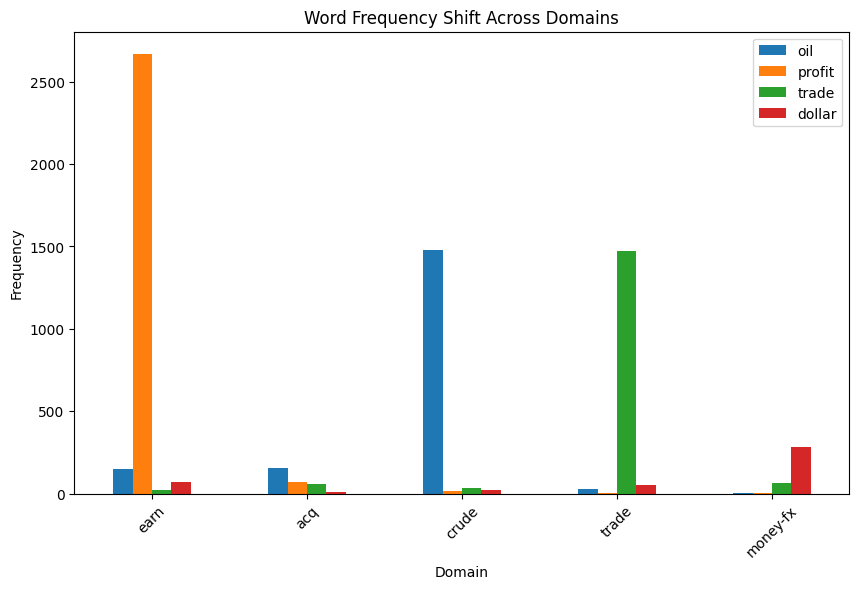

In [44]:
df.plot(kind="bar", figsize=(10,6))

plt.title("Word Frequency Shift Across Domains")
plt.xlabel("Domain")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [45]:
## 8. Conclusion
# The analysis shows that different domains exhibit distinct vocabulary distributions.  
# Words such as "oil", "profit", and "currency" appear predominantly in specific domains, demonstrating clear word frequency shifts across topics.